# 👗 Virtual Try-On with Gemini Vision

This notebook demonstrates AI-powered virtual try-on using Google's **Imagen 4.0** for image generation and the **Virtual Try-On** model via Vertex AI.

**Workflow:**
1. Generate a human model from a text prompt
2. Generate clothing items (tops, bottoms, shoes) from text descriptions
3. Apply virtual try-on — each item is applied sequentially onto the model

In [8]:
%pip install --upgrade --quiet google-genai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import typing
import io
import os

import IPython.display
from PIL import Image as PIL_Image
from PIL import ImageOps as PIL_ImageOps
from google import genai
from google.genai.types import (
    GenerateImagesConfig,
    Image,
    ProductImage,
    RecontextImageConfig,
    RecontextImageSource,
)
import matplotlib.image as img
import matplotlib.pyplot as plt
import numpy as np


def _save(image: Image, path: str) -> None:
    pil = typing.cast(PIL_Image.Image, image._pil_image)
    if pil.mode != "RGB":
        pil = pil.convert("RGB")
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    pil.save(path)


def _load(path: str) -> Image:
    buf = io.BytesIO()
    PIL_Image.open(path).save(buf, format="PNG")
    return Image(image_bytes=buf.getvalue())

## Configuration

Set your Google Cloud project ID and region. The client connects to Vertex AI.

In [27]:
PROJECT_ID = "virtual-try-on-490008"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
LOCATION = 'europe-west4'  # @param {type: "string", placeholder: "[location]", isTemplate: true}
virtual_try_on_model = "virtual-try-on-preview-08-04"
image_generation = "imagen-4.0-generate-001"
gemini_model = "gemini-2.5-flash"  # Vertex AI stable alias (no -001 suffix)

# Main client for Imagen + Virtual Try-On (europe-west4)
client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

# Separate client for Gemini (us-central1 has the broadest model availability)
gemini_client = genai.Client(vertexai=True, project=PROJECT_ID, location="us-central1")


In [11]:
# ── Input paths — edit these to point to your images ──────────────────────────

# Path to your person photo
PERSON_IMAGE = "./people/lady-in-jeans.png"

# Paths to clothing items to try on (applied sequentially)
CLOTHING_IMAGES = [
    "./clothing/cloth1.jpg",
    "./clothing/cloth2.jpg"
]

# Folder where results will be saved
OUTPUT_DIR = "output"

## Display Helper Functions

Utility functions for displaying generated images in the notebook.

In [12]:
def display_image(
    image,
    max_width: int = 400,
    max_height: int = 400,
) -> None:
    pil_image = typing.cast(PIL_Image.Image, image._pil_image)
    if pil_image.mode != "RGB":
        # RGB is supported by all Jupyter environments (e.g. RGBA is not yet)
        pil_image = pil_image.convert("RGB")
    image_width, image_height = pil_image.size
    if max_width < image_width or max_height < image_height:
        # Resize to display a smaller notebook image
        pil_image = PIL_ImageOps.contain(pil_image, (max_width, max_height))
    IPython.display.display(pil_image)


def display_local_image(
    images: list[str],
) -> None:
    fig, axes = plt.subplots(1, len(images), figsize=(12, 6))
    if len(images) == 1:
        axes = np.array([axes])
    for i, ax in enumerate(axes):
        image = img.imread(images[i])
        ax.imshow(image)
        ax.axis("off")
    plt.show()

## Virtual Try-On Function

Applies a clothing product image onto a person image using the Virtual Try-On model.

In [13]:
def virtual_try_on(person_image: Image, product_images: Image, save_path: str = None) -> Image:
    if save_path and os.path.exists(save_path):
        print(f"[loaded] {save_path}")
        return _load(save_path)

    response = client.models.recontext_image(
        model=virtual_try_on_model,
        source=RecontextImageSource(
            person_image=person_image,
            product_images=[
                ProductImage(product_image=product_images)
            ],
        ),
        config=RecontextImageConfig(
            base_steps=32,
            number_of_images=1,
            safety_filter_level="BLOCK_LOW_AND_ABOVE",
            person_generation="ALLOW_ADULT",
        ),
    )
    result = response.generated_images[0].image
    if save_path:
        _save(result, save_path)
        print(f"[saved] {save_path}")
    return result

## Image Generation Function

Generates a single image from a text prompt using Imagen 4.0.

In [14]:
def generate_image(prompt: str, save_path: str = None, no_human=True) -> Image:
    if save_path and os.path.exists(save_path):
        print(f"[loaded] {save_path}")
        return _load(save_path)

    image = client.models.generate_images(
        model=image_generation,
        prompt=prompt,
        config=GenerateImagesConfig(
            number_of_images=1,
            image_size="1K",  # 2k is the max resolution supported now
            safety_filter_level="BLOCK_LOW_AND_ABOVE",
            person_generation="ALLOW_ADULT",
        ),
    )
    result = image.generated_images[0].image
    if save_path:
        _save(result, save_path)
        print(f"[saved] {save_path}")
    return result

## Run Virtual Try-On

The `try_it` function generates a human model, then iterates through each clothing item — generating the item and applying virtual try-on one at a time. Applying multiple items simultaneously is not currently supported.

In [28]:
def try_it(person_image_path=PERSON_IMAGE, clothing_image_paths=CLOTHING_IMAGES, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)

    human_model = _load(person_image_path)
    print(f"Loaded person image: {person_image_path}")
    display_image(human_model)

    for idx, clothing_path in enumerate(clothing_image_paths):
        print(f"\nApplying clothing item {idx + 1}/{len(clothing_image_paths)}: {clothing_path}")
        item = _load(clothing_path)
        display_image(item)

        save_path = f"{output_dir}/tryon_{idx + 1}.png"
        human_model = virtual_try_on(human_model, item, save_path=save_path)
        print("Try-on result:")
        display_image(human_model)

Loaded person image: ./people/lady-in-jeans.png


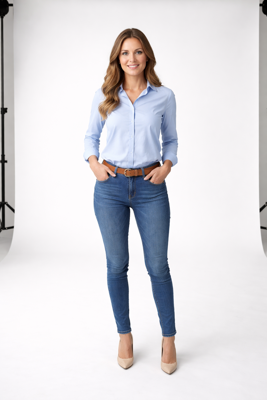


Applying clothing item 1/2: ./clothing/cloth1.jpg


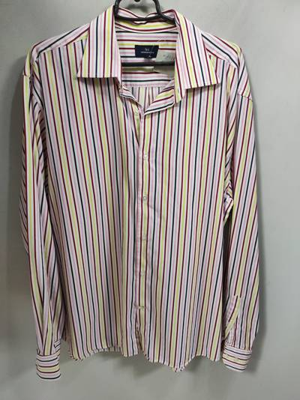

[loaded] output/tryon_1.png
Try-on result:


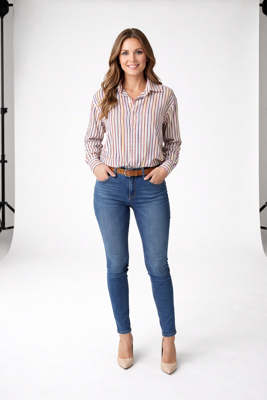


Applying clothing item 2/2: ./clothing/cloth2.jpg


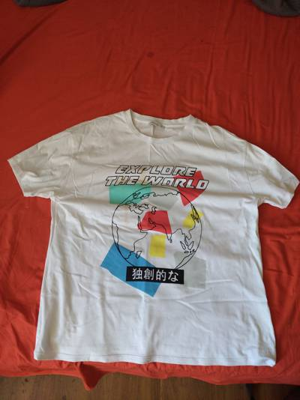

[loaded] output/tryon_2.png
Try-on result:


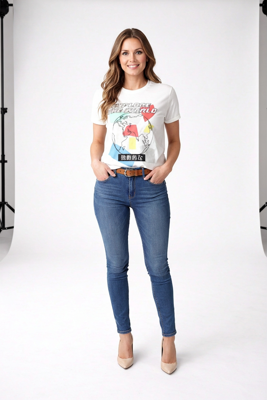

In [16]:
try_it()

## Style Suggestions — Find What to Match It With

Given **one clothing item**, `style_it` will:
1. Use **Gemini Vision** to detect the garment type and gender target
2. Ask Gemini to propose **3 distinct full-outfit styles** built around that exact item
3. Generate a full-body model image for each look with **Imagen 4.0**
4. Apply the exact clothing item on each model via **Virtual Try-On**


In [ ]:

import json
import io as _io
from google.genai import types as genai_types

# Schema for structured Gemini output — guarantees valid JSON
_STYLE_SCHEMA = {
    "type": "object",
    "properties": {
        "gender": {"type": "string", "enum": ["man", "woman"]},
        "item_description": {"type": "string"},
        "styles": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "name":          {"type": "string"},
                    "description":   {"type": "string"},
                    "outfit_prompt": {"type": "string"},
                },
                "required": ["name", "description", "outfit_prompt"],
            },
        },
    },
    "required": ["gender", "item_description", "styles"],
}


def style_it(clothing_path: str, gender: str = None, output_dir: str = None):
    """
    Given a single clothing item, generate 3 styled looks using Gemini + Imagen + Virtual Try-On.

    Args:
        clothing_path: Path to the clothing item image.
        gender:        'man' or 'woman'. Auto-detected via Gemini Vision when not provided.
        output_dir:    Folder where results are saved. Defaults to OUTPUT_DIR.
    """
    if output_dir is None:
        output_dir = OUTPUT_DIR
    os.makedirs(output_dir, exist_ok=True)

    # Load and display the clothing item
    clothing_image = _load(clothing_path)
    print(f"Styling item: {clothing_path}")
    display_image(clothing_image)

    # Read image bytes for Gemini Vision
    buf = _io.BytesIO()
    PIL_Image.open(clothing_path).save(buf, format="PNG")
    image_bytes = buf.getvalue()

    # When gender is known upfront, tell Gemini explicitly so outfit_prompts target the right gender
    if gender:
        gender_instruction = f"The clothing is for a {gender}."
        gender_phrase = f"a {gender}"
    else:
        gender_instruction = "Detect whether it is for a man or a woman."
        gender_phrase = "the detected gender (man or woman)"

    analysis_prompt = (
        "You are a professional fashion stylist. Analyse this clothing item. "
        f"{gender_instruction} "
        "Return exactly 3 distinct full-outfit style suggestions that feature this exact item. "
        "For each style include: a short style name, a one-sentence description, and an outfit_prompt "
        f"suitable for Imagen image generation — a full-body fashion photo of {gender_phrase} "
        "wearing this exact item plus complementary clothing and accessories, "
        "professional photography, white studio background, full body visible from head to toe."
    )

    img_part = genai_types.Part.from_bytes(data=image_bytes, mime_type="image/png")
    gemini_response = gemini_client.models.generate_content(
        model=gemini_model,
        contents=[img_part, analysis_prompt],
        config=genai_types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=_STYLE_SCHEMA,
        ),
    )

    analysis = json.loads(gemini_response.text)

    detected_gender = gender or analysis.get("gender", "woman")
    item_desc       = analysis.get("item_description", "clothing item")
    styles          = analysis.get("styles", [])[:3]

    print(f"\nDetected gender : {detected_gender}")
    print(f"Item            : {item_desc}")
    print(f"\nGenerating {len(styles)} styled looks...\n")

    for idx, style in enumerate(styles):
        print("-" * 55)
        print(f"Look {idx + 1}: {style['name']}")
        print(f"  {style.get('description', '')}")

        # Reinforce the correct gender in the Imagen prompt to prevent gender mismatch
        outfit_prompt = f"full body portrait of a {detected_gender}, {style['outfit_prompt']}"

        # 1. Generate a full-body model wearing the complete outfit
        model_save = os.path.join(output_dir, f"style_{idx + 1}_model.png")
        print("\nGenerating model image...")
        model_image = generate_image(outfit_prompt, save_path=model_save)
        display_image(model_image)

        # 2. Apply the exact clothing item via Virtual Try-On
        tryon_save = os.path.join(output_dir, f"style_{idx + 1}_tryon.png")
        print("Applying virtual try-on...")
        result = virtual_try_on(model_image, clothing_image, save_path=tryon_save)
        print("Final look:")
        display_image(result)
        print()


Styling item: ./clothing/cloth1.jpg


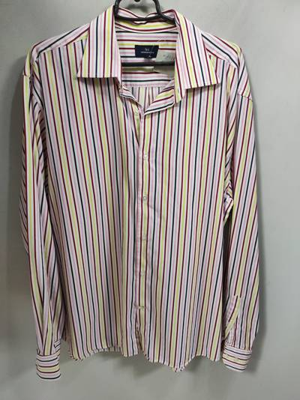


Detected gender : man
Item            : a long-sleeved button-down shirt with vertical stripes in shades of pink, yellow, and burgundy

Generating 3 styled looks...

-------------------------------------------------------
Look 1: Casual Weekend
  A relaxed and comfortable outfit perfect for weekend outings or casual gatherings.

Generating model image...
[saved] output\style_1_model.png


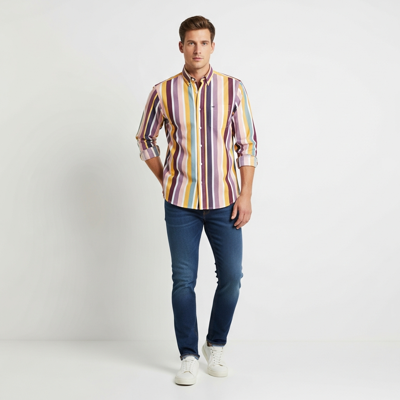

Applying virtual try-on...
[saved] output\style_1_tryon.png
Final look:


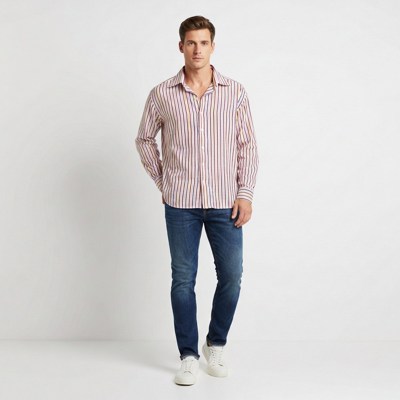


-------------------------------------------------------
Look 2: Smart Casual
  A polished yet relaxed ensemble suitable for office casual days or evening social events.

Generating model image...
[saved] output\style_2_model.png


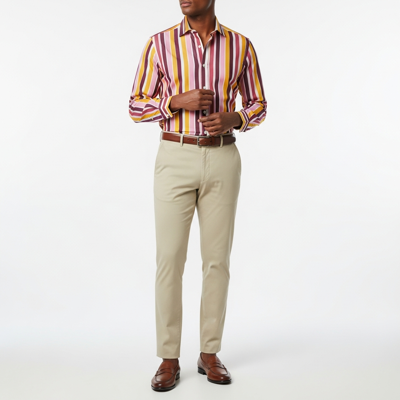

Applying virtual try-on...
[saved] output\style_2_tryon.png
Final look:


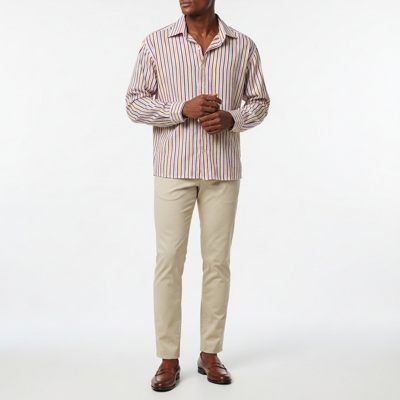


-------------------------------------------------------
Look 3: Summer Ready
  A fresh and vibrant look ideal for warm weather events or a vacation day out.

Generating model image...
[saved] output\style_3_model.png


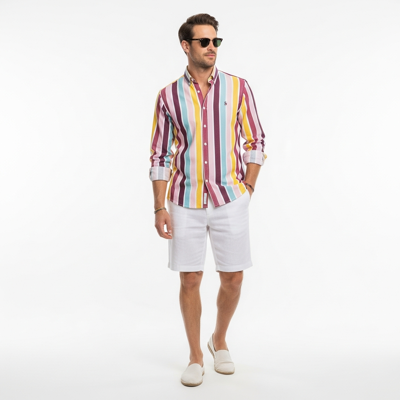

Applying virtual try-on...
[saved] output\style_3_tryon.png
Final look:


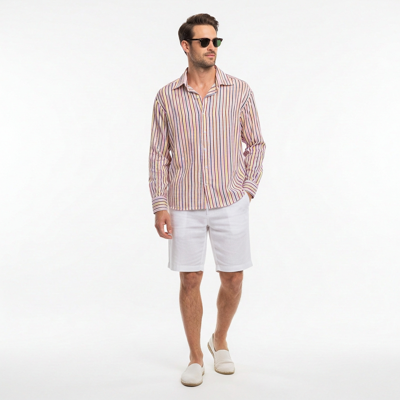

In [31]:
# Change clothing_path to whatever item you want to style
style_it(clothing_path=CLOTHING_IMAGES[0])